# 03b. Two deeper looks at the finished model

*Rent Reality Check (London). Created by Kevin Steepan.*

---

## What this is

Notebook 03 built and checked the price model. This is an optional appendix with two
deeper looks that would have made that notebook too long:

1. **Partial dependence and ICE plots.** SHAP told us, for one listing, how much
   each feature moved its price. These plots answer a different question: across
   all listings, what is the *shape* of the relationship between a feature and the
   price?
2. **Which listings does the model most disagree with?** Running the model over
   every listing and looking at the biggest gaps in each direction: the ones the
   model thinks are overpriced, and the ones it thinks are a bargain.

Both load the saved model. Nothing is re-trained except a quick set of
cross-validation folds for part 2.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from londonrent.features import build_model_frame
from londonrent import model as M
from londonrent.config import PROJECT_ROOT

# the cold-start feature set (no reviews), same as the shipped model
frame, groups = build_model_frame(with_reviews=False)
y = frame["log_price"].to_numpy()
bundle = M.load_bundle(PROJECT_ROOT / "models" / "price_model.joblib")
enc, gbr = bundle["encoder"], bundle["model"]
X = M.build_design_matrix(frame, groups, enc)
print(f"{len(frame):,} listings, design matrix {X.shape}")

59,450 listings, design matrix (59450, 72)


## Part 1. Partial dependence (PDP) and ICE

### The plain idea

Pick a feature, say "metres to the nearest station". Sweep it across its range. At
each swept value, ask the model to re-predict the price for a listing while
pretending that is its distance to a station, keeping everything else about the
listing the same. Do that for many listings and average the predictions: that
average curve is the **partial dependence plot**. It shows the average shape of
"price as a function of this one feature".

If instead of averaging you keep one line per listing, you get **ICE** (individual
conditional expectation). If all the lines are roughly parallel, the feature
affects every listing the same way. If they fan out or cross, the effect *depends*
on the listing, which means the feature interacts with something else.

### How it is computed here, step by step

For the feature `dist_station_m`:

1. Take a grid of values, e.g. 40 points from the 5th to the 95th percentile of the
   real distances.
2. For each grid value `g`: copy the design matrix, overwrite the whole
   `dist_station_m` column with `g`, and run `gbr.predict`.
3. The mean of those predictions at `g` is one point on the PDP. Each row's
   prediction at `g` is one point on that row's ICE line.
4. Plot predicted **log price** on the y axis (the model's native output; multiply
   through `exp` for pounds).

`scikit-learn`'s `PartialDependenceDisplay` does exactly this.

> **Deeper: the assumption to keep in mind.** Step 2 pretends you can move a
> listing's distance to a station without changing anything else. That is fine in
> the middle of the data and false at the edges: setting a Zone 1 flat's
> `dist_station_m` to 3000 m invents a listing that does not exist (nothing that
> central is 3 km from a station). So read the curves only where real data lives.
> The rug marks at the bottom of each plot show where the real values are.
>
> Where this comes from: PDP is from Friedman (2001), "Greedy Function
> Approximation". ICE is from Goldstein et al. (2015), "Peeking Inside the Black
> Box". Both are in the scikit-learn "Partial Dependence and Individual Conditional
> Expectation plots" user guide.

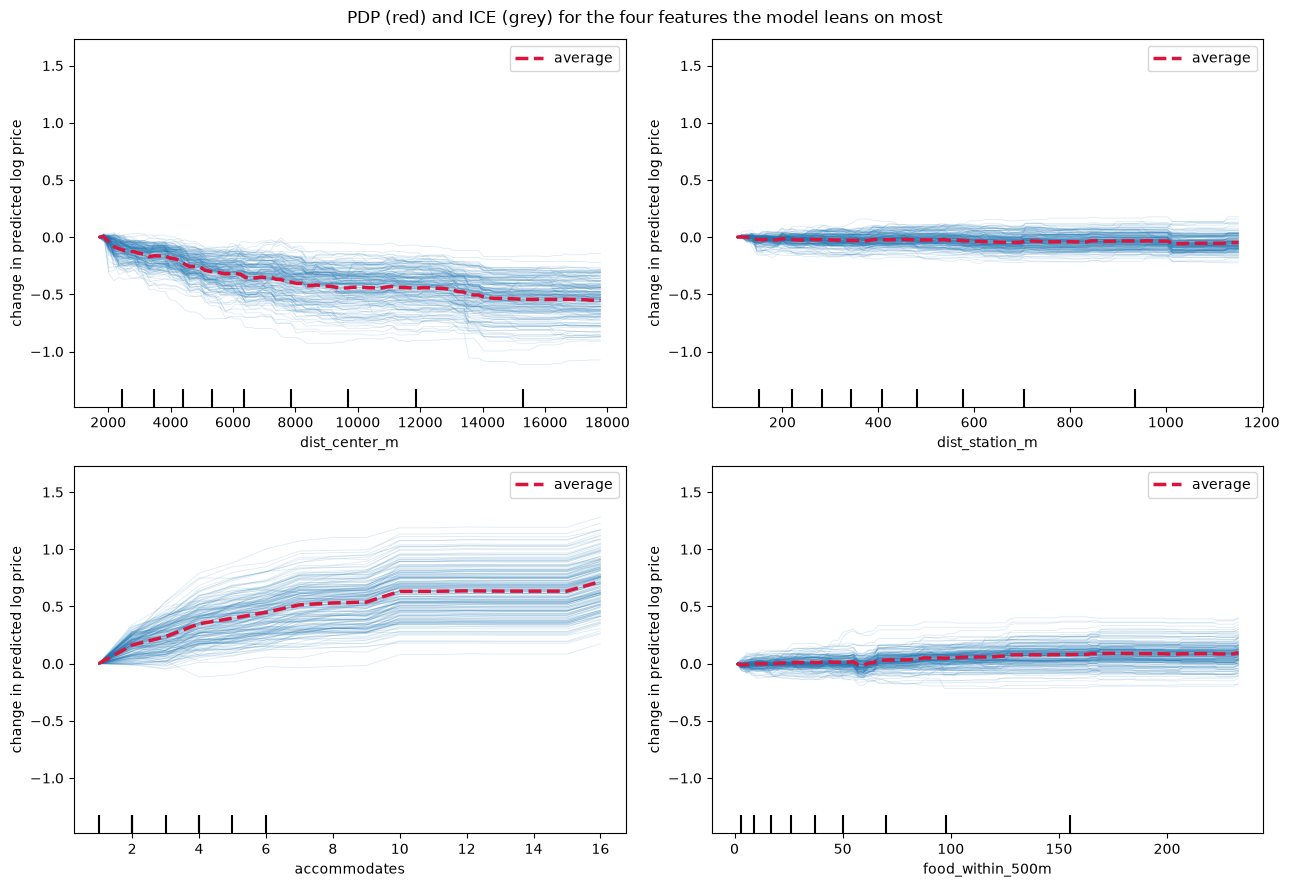

In [2]:
from sklearn.inspection import PartialDependenceDisplay

feats = ["dist_center_m", "dist_station_m", "accommodates", "food_within_500m"]

# the design matrix is float32 to save memory; PDP builds a float64 value grid
# and pandas refuses to place those values into float32 columns, so give PDP a
# float64 view. (Predicting on float64 is fine; sklearn casts internally.)
Xf = X.astype("float64")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
PartialDependenceDisplay.from_estimator(
    gbr, Xf, feats,
    kind="both",              # both the average (PDP) and the per-listing lines (ICE)
    subsample=200,            # 200 ICE lines, enough to see the spread
    centered=True,            # start every ICE line at 0 so the SHAPE is comparable
    n_jobs=-1, random_state=0,
    ax=axes.ravel().tolist(),
    ice_lines_kw={"alpha": 0.15, "linewidth": 0.6},
    pd_line_kw={"color": "crimson", "linewidth": 2.5},
)
for ax in axes.ravel():
    ax.set_ylabel("change in predicted log price")
fig.suptitle("PDP (red) and ICE (grey) for the four features the model leans on most")
plt.tight_layout()

**What we see.**

- **`dist_center_m`:** a clear downward slope, roughly -0.5 in log price (about
  -40%) from the centre out to the edge, with a step down past ~14 km. The ICE
  lines fan out a lot: distance to the centre matters much more for some listings
  than others, which is the model using an interaction (it costs a central
  entire-home more to be pushed out than it costs an outer private room).
- **`dist_station_m`:** almost flat. This is the interesting one. Once the model
  knows how central a listing is (and which borough it is in), the *extra*
  average effect of walking distance to a station is close to zero. It does not
  mean the feature is useless: SHAP showed it contributes to individual
  predictions. It means `dist_center_m` and `dist_station_m` carry overlapping
  "how connected is this" information, and the model puts most of that weight on
  distance to the centre.
- **`accommodates`:** a clean, roughly monotonic rise, about +0.65 in log price
  (roughly doubling) from sleeps-1 to sleeps-10, then flattening. This is the
  single strongest driver and the shape makes sense.
- **`food_within_500m`:** a gentle positive slope of about +0.1 in log price
  (about +10%) that saturates. A real but second-order effect.

The `dist_station_m` result is a good example of why PDP is worth doing: a SHAP
bar or a linear coefficient would still show station distance "mattering", because
it does for individual listings, but the average marginal shape reveals that the
model has folded most of that signal into distance-to-centre.

## Part 2. Which listings does the model most disagree with?

### The idea

Run the model over every listing, compare its prediction to the real price, and
list the biggest gaps in each direction:

- **actual far above the prediction:** the model thinks this listing is priced
  ambitiously, or it is missing something the host can see (a view, a recent
  refit, a specific quiet street).
- **actual far below the prediction:** the model thinks this is a bargain, or the
  listing is a special case (a long-stay rate, a room mislabelled as a whole
  place).

Both readings are worth stating. "The model thinks X" is not "X is true". But a
host would want to look hard at anything the model flags as underpriced.

### Why out-of-fold predictions

If a listing was in the training set, the model has partly memorised it, and its
"gap" would understate the real disagreement. So we predict each listing with a
model trained on the *other* spatial folds, exactly the setup from notebook 03.

In [3]:
folds = M.spatial_block_folds(frame["latitude"].to_numpy(),
                              frame["longitude"].to_numpy(), n_splits=5, seed=0)
oof = np.full(len(y), np.nan)
for tr, te in folds:
    m = M.make_model()
    m.fit(X.iloc[tr], y[tr])
    oof[te] = m.predict(X.iloc[te])

d = frame[["neighbourhood_cleansed", "room_type", "property_class",
           "accommodates", "bedrooms", "price"]].copy()
d["predicted"] = np.exp(oof).round(0)
d["gap_gbp"] = (d["price"] - d["predicted"]).round(0)          # + = dearer than model
d["gap_pct"] = (d["gap_gbp"] / d["price"]).round(2)

# keep plausible listings only, so we are not just re-finding the £10 / £1000 junk
plaus = d[d["price"].between(40, 500)].copy()
print(f"{len(plaus):,} listings in the £40 to £500 window")

54,044 listings in the £40 to £500 window


In [4]:
cols = ["neighbourhood_cleansed", "room_type", "accommodates", "bedrooms",
        "price", "predicted", "gap_gbp", "gap_pct"]

print("=== model says OVERPRICED (actual well above prediction) ===")
print(plaus.sort_values("gap_pct", ascending=False).head(10)[cols].to_string(index=False))

print("\n=== model says UNDERPRICED / a bargain (actual well below prediction) ===")
print(plaus.sort_values("gap_pct").head(10)[cols].to_string(index=False))

=== model says OVERPRICED (actual well above prediction) ===
neighbourhood_cleansed    room_type  accommodates  bedrooms   price  predicted  gap_gbp  gap_pct
         Tower Hamlets Private room             1       NaN   475.0       61.0    414.0     0.87
              Hounslow Private room             1       NaN  342.67       46.0    297.0     0.87
              Hounslow Private room             1       NaN   343.0       45.0    298.0     0.87
              Hounslow Private room             1       NaN  342.67       47.0    296.0     0.86
  Barking and Dagenham Private room             1       NaN   447.0       64.0    383.0     0.86
               Hackney Private room             1       NaN  396.21       54.0    342.0     0.86
               Croydon Private room             2       NaN   355.0       51.0    304.0     0.86
                Ealing Private room             1       NaN   500.0       73.0    427.0     0.85
               Hackney Private room             1       NaN   450.

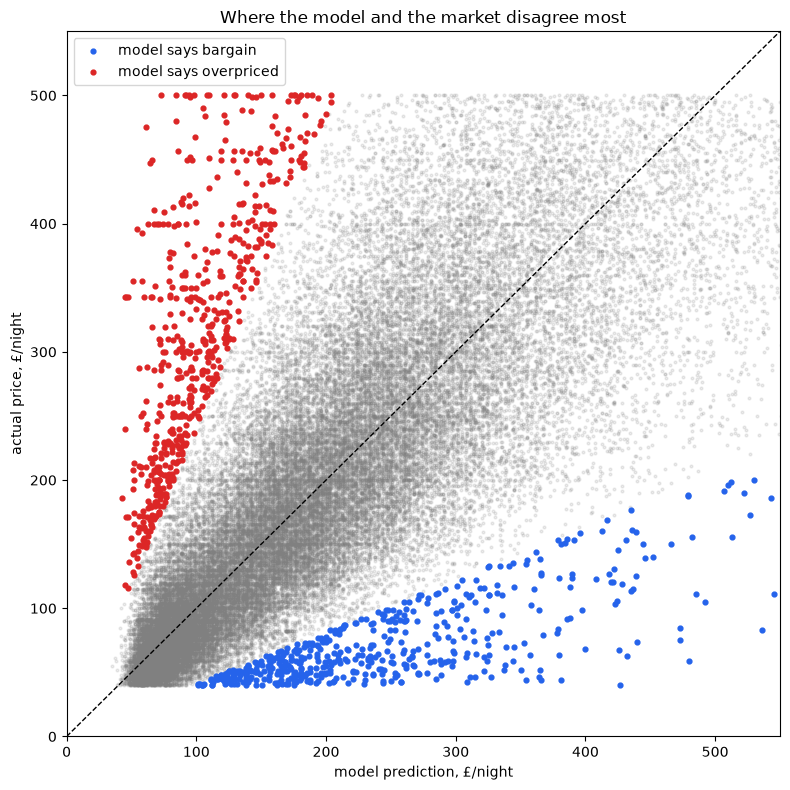

In [5]:
# the same thing as a picture: predicted vs actual, with the 1% most disagreed-with
# listings in each direction highlighted
lo = plaus["gap_pct"].quantile(0.01)
hi = plaus["gap_pct"].quantile(0.99)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(plaus["predicted"], plaus["price"], s=4, alpha=.15, color="grey")
under = plaus[plaus["gap_pct"] <= lo]
over = plaus[plaus["gap_pct"] >= hi]
ax.scatter(under["predicted"], under["price"], s=12, color="#2563eb", label="model says bargain")
ax.scatter(over["predicted"], over["price"], s=12, color="#dc2626", label="model says overpriced")
lim = [0, 550]
ax.plot(lim, lim, "k--", lw=1)
ax.set(xlim=lim, ylim=lim, xlabel="model prediction, £/night",
       ylabel="actual price, £/night", title="Where the model and the market disagree most")
ax.legend()
plt.tight_layout()

**What we see.**

With the £40 to £500 filter, both extremes are dominated by **data-entry
artefacts**, not genuine mispricing:

- **"Overpriced":** almost all are *private rooms that sleep one*, listed at
  £340 to £500 a night, that the model prices at £45 to £75. A single private room
  is not really £475 a night. These are most likely calendars blocked with a
  deterrent price, or a longer-stay total entered as a nightly rate. The model is
  right to disbelieve them.
- **"Bargain":** almost all are *entire flats in Westminster (and Islington,
  Wandsworth) that sleep four to seven*, listed at £40 to £58 a night, that the
  model prices at £300 to £480. A two-bed entire flat in Westminster is not £45 a
  night. Again, most likely a monthly rate entered as nightly.

The scatter shows this cleanly: the flagged points sit far off the diagonal, and
the "bargain" cluster piles up against the £40 filter floor.

**So the honest read is:** a naive "biggest gap" scan mostly surfaces junk. A
version that finds *real* mispricing would need a per-prediction confidence
interval (quantile regression) and a plausibility filter on the listing itself
(has reviews, a sane minimum-nights value, a calendar that is actually open). That
is a genuine next step, not a finished result.

## Takeaways

- **PDP and ICE** show the model learned sensible non-linear shapes: a strong,
  fanning effect of distance to the centre; a clean rising effect of size; a small
  saturating effect of nearby food. And a surprise: the average marginal effect of
  distance to a *station* is close to flat once centrality is known, because the
  two features overlap and the model leans on distance-to-centre.
- **The disagreement scan** as written mostly finds data-entry artefacts, which is
  itself worth knowing. Turning it into a real mispricing detector needs
  prediction intervals and a listing-plausibility filter. Listed on the "what I
  would do next" section of `FINDINGS.md`.